# <center> 四 LangGraph中的单代理架构应用(上)

&emsp;&emsp;在掌握了`LangGraph`的`State`状态定义模式后，我们就可以围绕`LangGraph`的`State`进入更高级的功能开发和探索阶段。

&emsp;&emsp;我们首先要探讨的是`LangGraph`中的代理架构，即在`LangGraph`框架下都能够通过哪些代理模型来构建应用。我们希望`AI Agent`程序带来的是更多的智能化，意味着我们希望仅仅输入一个需求，而无需关心处理过程的具体细节。随着应用变得越来越复杂，也自然而然要求基于大模型构建的系统能够具体更多的控制权限，从而才能解决更复杂的问题。

&emsp;&emsp;基于不同的需求场景，衍生出许多不同类型的代理架构，来赋予大模型不同级别的控制权，如下图所示：

<div align=center><img src="../pic/lesson04/1.png" width=80%></div>

&emsp;&emsp;在代理架构模式下，大模型能通过多种方式进行操作控制。最基本的功能是在两个潜在路径之间做出选择。进而在每条路径上，如果存在多个可用工具，大模型能够自主决定调用哪一个。更复杂的情况下，它还能评估生成的答案是否满足问题的需求。如有必要进行额外工作，它将自行执行，直到得到一个充分满足条件的答案为止。**`LangGraph`框架则是从这个角度出发，接入了路由代理，工具代理，自主循环代理以及多代理这四大类代理架构，以支持不同的场景需求。**

&emsp;&emsp;因此，我们从本节课开始，就依次来介绍并实践以上四类不同的代理架构在`LangGraph`框架下的应用方法。首先来看较为基础的`Router Agent`，即路由代理。

## 1. LangGraph中的Router使用场景

&emsp;&emsp;在`LangGraph`中，我们可以利用“条件边”这一概念来指导或约束大模型在处理特定任务时的逻辑流程。这种机制允许大模型在达到某一环节并满足预设条件时，根据不同的条件输出或数据，选择性地执行不同的逻辑路径。如下图所示：

<div align=center><img src="../pic/lesson04/2.png" width=60%></div>

&emsp;&emsp;为了管理这样复杂的图结构，`LangGraph`使用的是一个类似于 `if-else`语句的结构组件，称为`Router`（路由）。这个组件允许大模型从一组预设的选项中选择合适的步骤来进行执行。这个设计思路并不难理解，同时由于`LangGraph`的底层封装，实现起来也非常简单，我们看下面的代码：

&emsp;&emsp;首先，对于简单的直接从节点`A`到节点`B`，我们一直使用的是`add_edge`方法，即：

In [1]:
from langgraph.graph import START, StateGraph, END
from langgraph.graph import StateGraph

def node_a(state):
    return {"x": state["x"] + 1}

def node_b(state):
    return {"x": state["x"] - 2}

builder = StateGraph(dict)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)

# 构建节点之间的边
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)

graph = builder.compile()

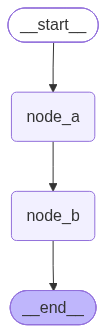

In [2]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

&emsp;&emsp;如果想选择性地路由到 1 个或多个边，则需要使用`add_conditional_edges`方法。该方法也在`Graph`的基类中进行了定义，如下所示：

```python

class Graph:
    def __init__(self) -> None:
        self.nodes: dict[str, NodeSpec] = {}
        self.edges = set[tuple[str, str]]()
        self.branches: defaultdict[str, dict[str, Branch]] = defaultdict(dict)
        self.support_multiple_edges = False
        self.compiled = False

    def add_conditional_edges(
        self,
        source: str,    # 起始节点
        path: Union[    #  这是一个可调用对象，其返回值决定接下来执行的节点。这个函数可以是简单的 Python 函数，或者是任何可以被调用来决定分支路径的对象。
            Callable[..., Union[Hashable, list[Hashable]]],
            Callable[..., Awaitable[Union[Hashable, list[Hashable]]]],
            Runnable[Any, Union[Hashable, list[Hashable]]],
        ],
        path_map: Optional[Union[dict[Hashable, str], list[str]]] = None,  # 路径到节点名称的可选映射。如果省略， path返回的路径应该是节点名称。
        then: Optional[str] = None,  # 在path选择的节点之后执行的节点的名称。
    ) -> Self:
```

> add_conditional_edges 源码：https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.graph.Graph

&emsp;&emsp;根据源码的定义我们可以非常明确的分析出其调用过程。这里我们要关注`path`参数，它指的是一个函数调用对象，与普通的节点类似， 这个对象接受图的当前`state`并返回一个值，根据返回值的不同，来决定路由到哪个节点。比如想构建一个带有路由的图结构，这里我们定义一个 `routing_function` 作为路由函数，并添加一个新的节点`node_c`，代码如下所示：

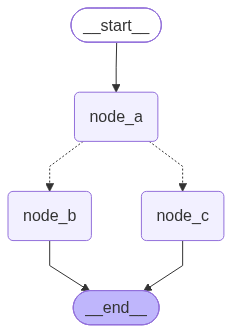

In [7]:
from langgraph.graph import START, StateGraph, END
from langgraph.graph import StateGraph
from IPython.display import Image, display
from typing import TypedDict, Literal

class state(TypedDict):
    x: int

def node_a(state):
    return {"x": state["x"] + 1}

def node_b(state):
    return {"x": state["x"] - 2}

def node_c(state):
    return {"x": state["x"] + 1}

def routing_function(state) -> Literal["node_b","node_c"]:
    if state["x"] == 10:
        return "node_b"
    else:
        return "node_c"


builder = StateGraph(state)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.set_entry_point("node_a")

# 构建节点之间的边
builder.add_conditional_edges("node_a", routing_function)
builder.add_edge("node_b",END)
builder.add_edge("node_c",END )


graph = builder.compile()

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

&emsp;&emsp;默认情况下，`routing_function`路由函数的返回值用作将状态发送到下一个的节点（或节点列表）的名称。除此之外，还可以使用`path_map`参数，通过一个字典的数据结构将`routing_function`的输出映射到下一个节点的名称。这里改动如下：

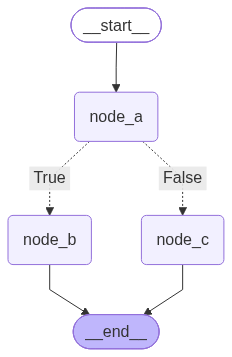

In [11]:
from langgraph.graph import START, StateGraph, END
from langgraph.graph import StateGraph
from typing import TypedDict, Literal

class state(TypedDict):
    x: int

def node_a(state):
    return {"x": state["x"] + 1}

def node_b(state):
    return {"x": state["x"] - 2}

def node_c(state):
    return {"x": state["x"] + 1}

def routing_function() -> Literal[True, False]:
    if state["x"] == 10:
        return True
    else:
        return False

builder = StateGraph(state)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.set_entry_point("node_a")

# 构建节点之间的边
builder.add_conditional_edges("node_a", routing_function, {True: "node_b", False: "node_c"})

builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

&emsp;&emsp;通过上述实践，大家也能体会到在`LangGraph`中去构建条件边并非难事，我们考虑这样一个现实意义的场景：一般来说，`Agent`是可以接收各种形式的输入，并通过预设的路由逻辑来确定执行的具体操作。如图所示，`Agent`的开始节点（Start）接收输入数据，这些输入可以是查询请求（例如“name: muyu, age: 18, phone: 123”或“Hello”）。根据输入的不同，流程通过`Router`函数进行决策，将不同的输入引导到正确的处理流程。

<div align=center><img src="../pic/lesson04/3.png" width=80%></div>

&emsp;&emsp;这里的核心是`Router function` ，它根据输入数据的结构和内容，动态地决定下一步应该执行的节点。例如，对于具体的查询请求，`Router`决定需要访问数据库（Mysql节点），而对于简单的问候（如"Hello"），则直接返回一个响应（Response节点）。每个决策路径最终都指向一个结束节点（End）。所以我们要明确的是，**在构建实际的`Agent`时，`Router fuction`的定义才是最关键且最重要的。**我们需要在这个函数中，基于特定的一些格式或者标识来区分该执行哪一条分支的逻辑。而**对于消息的传递，大模型往往是通过结构化输出，引导其在响应的过程中应遵循哪种模式来工作，就类似于工具调用过程。`Router`就很好的利用到了这个特性，通过结构化输出的特性来控制接下来的分支路径。**

&emsp;&emsp;这里我们先来了解一下什么是结构化输出。在`LangGraph`中，实现结构化输出可以通过以下三种有效方式完成：
- 提示工程：指示大模型以特定格式做出回应。
- 输出解析器：采用后处理的方法从大模型的响应中提取结构化数据。
- 工具调用：利用一些内置工具调用功能来生成结构化输出。

- **提示工程**

In [1]:
import getpass
import os


from langchain_openai import ChatOpenAI

key = "your-deepseek-api-key"
base_url = "https://api.deepseek.com/v1"
llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

In [2]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the user query. Wrap the output in `json`",
        ),
        ("human", "{query}"),
    ]
)

In [3]:
chain = prompt | llm 

In [4]:
ans = chain.invoke({"query": "我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111"})

In [5]:
ans.content

'```json\n{\n  "name": "奥特曼",\n  "age": 38,\n  "email": "aoteman#qq.com",\n  "phone": "1211111111"\n}\n```'

&emsp;&emsp;直接通过提示工程让大模型生成特定格式的输出虽然是可行的，但这种方法在复杂的`Agent`构建流程中非常并不稳定。一个进阶的**优化方法是：引入后处理步骤，通过输出解析器来格式化大模型生成的响应。**这种做法可以提高输出的准确性和一致性，这种形式的实现方法如下所示：

- **提示工程 + 输出解析器**

In [6]:
from langchain_core.messages import AIMessage
import json
import re
from typing import List

def extract_json(message: AIMessage) -> List[dict]:
    """Extracts JSON content from a string where JSON is embedded between \`\`\`json and \`\`\` tags.

    Parameters:
        text (str): The text containing the JSON content.

    Returns:
        list: A list of extracted JSON strings.
    """
    text = message.content
    # 定义正则表达式模式来匹配JSON块
    pattern = r"\`\`\`json(.*?)\`\`\`"

    # 在字符串中查找模式的所有非重叠匹配
    matches = re.findall(pattern, text, re.DOTALL)

    # 返回匹配的JSON字符串列表，去掉任何开头或结尾的空格
    try:
        return [json.loads(match.strip()) for match in matches]
    except Exception:
        raise ValueError(f"Failed to parse: {message}")

<>:7: SyntaxWarning: invalid escape sequence '\`'
<>:7: SyntaxWarning: invalid escape sequence '\`'
/var/folders/hm/p5x9q0gj1tq37tdyp_pjmqgh0000gn/T/ipykernel_31050/2250407316.py:7: SyntaxWarning: invalid escape sequence '\`'
  """Extracts JSON content from a string where JSON is embedded between \`\`\`json and \`\`\` tags.


In [7]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the user query. Wrap the output in `json`",
        ),
        ("human", "{query}"),
    ]
)

In [8]:
chain = prompt | llm | extract_json

In [9]:
ans = chain.invoke({"query": "我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111"})

In [10]:
ans

[{'name': '奥特曼', 'age': 38, 'email': 'aoteman#qq.com', 'phone': '1211111111'}]

- **内置工具方法**

&emsp;&emsp;从结果可以明显看出，通过定制化的输出解析器得到的结果会更加的符合预期，而接下来我们要说的是，在`LangGraph`中我们更常用的，且效果更好的是，直接使用其内置的工具方法：`.with_structured_output()`。

&emsp;&emsp;这个方法通过接受一个定义了所需输出属性的名称、类型和描述的模式作为输入，进而生成一个类似模型的 `Runnable`。不同于常规模型输出字符串或消息，这个 `Runnable` 输出一个与输入模式相匹配的对象。可以通过几种方式指定这种架构，包括 `TypedDict` 类、`JSON Schema` 或 `Pydantic` 类。如果采用 `TypedDict` 或 `JSON Schema`，`Runnable` 将输出一个字典；若使用 `Pydantic` 类，则输出一个 `Pydantic` 对象。我们可以依次的来实践一下。

&emsp;&emsp;我们首先尝试和实践使用`Pydantic`类做格式化输出，应用的场景是：从文本中提取格式化的数据。

### 1.1 使用Pydantic做结构化输出

&emsp;&emsp;使用`Pydantic`去限定输出格式，可以确保所有通过此模型处理的数据都会符合指定的结构和数据类型，从而减少数据处理中的错误并增加代码的健壊性。此外，Pydantic的验证系统还会自动确保所有字段都符合预定义的格式，如果输入数据不符合预期，则会抛出错误。比如下面是一个用`Pydantic`定义用户信息模型的示例：

In [11]:
from typing import Optional
from pydantic import BaseModel, Field

# 定义 Pydantic 模型
class UserInfo(BaseModel):
    """Extracted user information, such as name, age, email, and phone number, if relevant."""
    name: str = Field(description="The name of the user")
    age: Optional[int] = Field(description="The age of the user")
    email: str = Field(description="The email address of the user")
    phone: Optional[str] = Field(description="The phone number of the user")

&emsp;&emsp;在这个`UserInfo`模型中：
- name（必需）: 存储用户的名字。
- age（可选）: 存储用户的年龄，这是一个可选字段。
- email（必需）: 存储用户的电子邮件地址。
- phone（可选）: 存储用户的电话号码，这也是一个可选字段。

&emsp;&emsp;对于`.with_structured_output()`方法，如果我们希望模型返回一个 `Pydantic` 对象，只需要传入所需的 `Pydantic` 类即可，即`UserInfo`，代码如下所示：

In [12]:
import getpass
import os


from langchain_openai import ChatOpenAI

key = "your-deepseek-api-key"
base_url = "https://api.deepseek.com/v1"
llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

In [13]:
structured_llm = llm.with_structured_output(UserInfo, method="function_calling")

In [14]:
structured_llm

RunnableBinding(bound=ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x12c3677a0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x12c573cb0>, root_client=<openai.OpenAI object at 0x12c1c0500>, root_async_client=<openai.AsyncOpenAI object at 0x12c573110>, model_name='deepseek-chat', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.deepseek.com/v1'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'UserInfo', 'description': 'Extracted user information, such as name, age, email, and phone number, if relevant.', 'parameters': {'properties': {'name': {'description': 'The name of the user', 'type': 'string'}, 'age': {'anyOf': [{'type': 'integer'}, {'type': 'null'}], 'description': 'The age of the user'}, 'email': {'description': 'The email address of the user', 'type': 'string'}, 'phone': {'anyOf': [{'type': 'string'}, {'type': 'null'

In [15]:
# 从非结构化文本中提取用户信息
extracted_user_info = structured_llm.invoke("我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111")

extracted_user_info

UserInfo(name='奥特曼', age=38, email='aoteman#qq.com', phone='1211111111')

In [16]:
# 从非结构化文本中提取用户信息
extracted_user_info = structured_llm.invoke("我叫三毛，今年38岁，邮箱地址是sanmao#qq.com，电话是1211111111")

extracted_user_info

UserInfo(name='三毛', age=38, email='sanmao#qq.com', phone='1211111111')

&emsp;&emsp;它返回的是一个`UserInfo`的`Pytantic`对象，每个字段中则填充了在原始非结构化文本中提取出来的结构化信息。经过这样的格式化输出呢，对于`Router function`中，我们就可以通过类似这样的伪代码去继续路由分支的选择，比如：

In [17]:
# isinstance 函数用于判断一个对象是否是一个已知的类型，或者是该类型的子类的实例
if isinstance(extracted_user_info, UserInfo):
    print("执行节点A的逻辑")
else:
    print("执行节点B的逻辑")

执行节点A的逻辑


In [18]:
extracted_user_info = "你好"

if isinstance(extracted_user_info, UserInfo):
    print("执行节点A的逻辑")
else:
    print("执行节点B的逻辑")

执行节点B的逻辑


&emsp;&emsp;这就是结构化输出对于`LangGraph`中路由函数逻辑判断的意义所在。除此之外，还有`TypedDict` 和 `JSON Schema`能够做到相同的效果，下面我们依次对这两种模式进行尝试。

### 1.2 使用TypedDict做结构化输出

&emsp;&emsp;如果不想使用 `Pydantic`去明确地验证输出参数，则可以使用 `TypedDict` 类定义结构化输出的模式。这就可以使用我们上节课详细介绍的特殊`Annotated`语法，添加对指定字段的默认值和描述。

In [19]:
from typing import Optional
from typing_extensions import Annotated, TypedDict


# 定义 TypedDict 模型
class UserInfo(TypedDict):
    """Extracted user information from text"""
    name: Annotated[str, ..., "The user's name"]
    age: Annotated[Optional[int], None, "The user's age"]
    email: Annotated[str, ..., "The user's email address"]
    phone: Annotated[Optional[str], None, "The user's phone number"]

In [20]:
structured_llm = llm.with_structured_output(UserInfo, method="function_calling")

# 从非结构化文本中提取用户信息
extracted_user_info = structured_llm.invoke("我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111")

extracted_user_info

{'name': '奥特曼', 'age': 38, 'email': 'aoteman#qq.com', 'phone': '1211111111'}

&emsp;&emsp;使用 `TypedDict` 创建的“对象”实际上是一个字典。它没有`Pydantic`模型那样的方法和属性，因此功能相对简单。`TypedDict` 主要用于静态类型检查，但它不会在运行时进行类型检查，但搭配着`LangGraph`中已实现的基本验证机制，也是一种不错的方法。

### 1.3 Json Schema

&emsp;&emsp;对于`Json Schema`格式大家应该最为熟悉，不需要导入或类，可以直接通过字典的形式清楚地准确记录每个参数，但代价是代码会更加冗长。如下所示`user_info` 的 `JSON Schema`，用于描述用户信息的结构，包括姓名、年龄、邮箱地址和电话号码。

In [21]:
# 定义 JSON Schema
json_schema = {
    "title": "user_info",
    "description": "Extracted user information",
    "type": "object",
    "properties": {
        "name": {
            "type": "string",
            "description": "The user's name",
        },
        "age": {
            "type": "integer",
            "description": "The user's age",
            "default": None,
        },
        "email": {
            "type": "string",
            "description": "The user's email address",
        },
        "phone": {
            "type": "string",
            "description": "The user's phone number",
            "default": None,
        },
    },
    "required": ["name", "email"],
}



structured_llm = llm.with_structured_output(json_schema, method="function_calling")

# 从非结构化文本中提取用户信息
extracted_user_info = structured_llm.invoke("我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111")

In [22]:
extracted_user_info

{'name': '奥特曼', 'age': 38, 'email': 'aoteman#qq.com', 'phone': '1211111111'}

### 1.4 结合结构化输出构建路由图

&emsp;&emsp;三种不同的结构化输出方法，我们更常使用的是用`Pydantic`来处理路由决策。在这种策略下，我们可以通过定义一个包含`Union`类型属性的父模型来灵活地从多种模式中选择适当的路由分支。例如，如果我们想根据输出决定是查询数据库还是直接回答问题，可以创建一个统一的模型来封装可能的输出类型。代码如下所示：

<div align=center><img src="../pic/lesson04/7.jpg" width=40%></div>

In [42]:
from typing import Union, Optional
from pydantic import BaseModel, Field

# 定义数据库插入的用户信息模型
class UserInfo(BaseModel):
    """Extracted user information, such as name, age, email, and phone number, if relevant."""
    name: str = Field(description="The name of the user")
    age: Optional[int] = Field(description="The age of the user")
    email: str = Field(description="The email address of the user")
    phone: Optional[str] = Field(description="The phone number of the user")


# 定义正常生成模型回复的模型
class ConversationalResponse(BaseModel):
    """Respond to the user's query in a conversational manner. Be kind and helpful."""
    response: str = Field(description="A conversational response to the user's query")


# 定义最终响应模型，可以是用户信息或一般响应
class FinalResponse(BaseModel):
    final_output: Union[UserInfo, ConversationalResponse]

&emsp;&emsp;这个扩展后的代码将用于提取和存储用户的基本信息，包括姓名、年龄、电子邮件地址和电话号码的`UserInfo`模型与用于生成面向用户的交流响应的`ConversationalResponse`模型统一的放在了`FinalResponse`模型中，使用`Union`类型来支持灵活的输出选项。`final_output`属性可以是`UserInfo`类型，也可以是`ConversationalResponse`类型，这使得系统可以根据不同的业务逻辑和用户输入决定输出的具体形式。例如，在用户请求个人数据时可以返回`UserInfo`，而在普通查询时则提供`ConversationalResponse`。

In [43]:
structured_llm = llm.with_structured_output(FinalResponse, method="function_calling")

In [44]:
# 从非结构化文本中提取用户信息或进行一般对话响应
extracted_user_info = structured_llm.invoke("你好")

extracted_user_info

FinalResponse(final_output=ConversationalResponse(response='你好！很高兴见到你。有什么我可以帮助你的吗？'))

In [45]:
extracted_user_info.final_output.response

'你好！很高兴见到你。有什么我可以帮助你的吗？'

In [46]:
# 从非结构化文本中提取用户信息
extracted_user_info = structured_llm.invoke("我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111")

extracted_user_info

FinalResponse(final_output=UserInfo(name='奥特曼', age=38, email='aoteman#qq.com', phone='1211111111'))

In [47]:
extracted_user_info.final_output

UserInfo(name='奥特曼', age=38, email='aoteman#qq.com', phone='1211111111')

&emsp;&emsp;掌握到这种程度，我们就可以利用这些判别条件作为`Router Function`来构建决策分支。通过使用`Pydantic`模型来提取结构化数据，能够在大语言模型（LLM）调用过程中将非结构化文本转换为结构化数据格式。这种转换使得我们构建的流程图能够根据用户的不同输入，智能判断是应当生成常规响应还是执行数据库操作。代码如下所示：

&emsp;&emsp;首先，还是定义`Pydantic`模型以及用于生成格式化输出的大模型实例。

In [48]:
import getpass
import os
from typing import Union, Optional
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 定义数据库插入的用户信息模型
class UserInfo(BaseModel):
    """Extracted user information, such as name, age, email, and phone number, if relevant."""
    name: str = Field(description="The name of the user")
    age: Optional[int] = Field(description="The age of the user")
    email: str = Field(description="The email address of the user")
    phone: Optional[str] = Field(description="The phone number of the user")


# 定义正常生成模型回复的模型
class ConversationalResponse(BaseModel):
    """Respond to the user's query in a conversational manner. Be kind and helpful."""
    response: str = Field(description="A conversational response to the user's query")



# 定义最终响应模型，可以是用户信息或一般响应
class FinalResponse(BaseModel):
    final_output: Union[UserInfo, ConversationalResponse]



# DeepSeek API 配置
key = "your-deepseek-api-key"
base_url = "https://api.deepseek.com/v1"

# 生成模型实例（DeepSeek 结构化输出需配合 method="function_calling"）
llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

&emsp;&emsp;接下来，考虑到设计的场景中用户需要执行数据库操作，我们首先需要实现一个连接数据库的函数。在这个示例中，我们选择使用MySQL数据库。基于`UserInfo`模型的定义，构建一个相应的表结构，以便支持后续的数据插入和更新操作。

#### MySQL 数据库安装步骤（macOS 本地）

**1. 检查并启动 MySQL 服务**

先检查 MySQL 是否已在运行：

```bash
pgrep -x mysqld && echo "MySQL is running" || echo "MySQL is not running"
```

- 若输出 `MySQL is running`，**跳过**下面的启动命令，直接进入第 2 步。
- 若输出 `MySQL is not running`，再执行启动命令：

```bash
sudo /usr/local/mysql/support-files/mysql.server start
```

**2. 登录 MySQL（本地 root 密码为 `root`）**

```bash
mysql -u root -p
```

**3. 创建数据库**

```sql
CREATE DATABASE IF NOT EXISTS langgraph CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci;
```

**4. （可选）创建专用账户**

```sql
CREATE USER 'gpt'@'localhost' IDENTIFIED BY 'gpt';
GRANT ALL PRIVILEGES ON langgraph.* TO 'gpt'@'localhost';
FLUSH PRIVILEGES;
```

> 下方代码默认使用 `root` / `root` 连接本地 MySQL。若你创建了 `gpt` 用户，请同步修改 `MYSQL_USER` 和 `MYSQL_PASSWORD`。

In [49]:
! pip install sqlalchemy pymysql

  Using cached pymysql-1.2.0-py3-none-any.whl.metadata (4.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 523.8 kB/s  0:00:04572.7 kB/s eta 0:00:01
Using cached pymysql-1.2.0-py3-none-any.whl (45 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pymysql]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [50]:
from sqlalchemy import create_engine, Column, Integer, String, text
from sqlalchemy.orm import declarative_base, sessionmaker

# 创建基类
Base = declarative_base()

# 定义 User 表模型
class User(Base):
    __tablename__ = 'users'
    id = Column(Integer, primary_key=True)
    name = Column(String(50))
    age = Column(Integer)
    email = Column(String(100))
    phone = Column(String(15))

# 数据库连接配置（macOS 本地 MySQL）
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_HOST = "localhost"
MYSQL_DATABASE = "langgraph"

# 先创建数据库（如果不存在）
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/?charset=utf8mb4"
)
with server_engine.connect() as conn:
    conn.execute(text(
        f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE} "
        "CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci"
    ))
    conn.commit()

DATABASE_URI = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/"
    f"{MYSQL_DATABASE}?charset=utf8mb4"
)
engine = create_engine(DATABASE_URI, echo=True)

# 如果表不存在，则创建表
Base.metadata.create_all(engine)

# 创建会话
Session = sessionmaker(bind=engine)
session = Session()

2026-08-09 11:11:58,412 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-08-09 11:11:58,412 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-09 11:11:58,413 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-08-09 11:11:58,413 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-09 11:11:58,414 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-08-09 11:11:58,414 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-09 11:11:58,415 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-09 11:11:58,415 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`users`
2026-08-09 11:11:58,415 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-08-09 11:11:58,417 INFO sqlalchemy.engine.Engine 
CREATE TABLE users (
	id INTEGER NOT NULL AUTO_INCREMENT, 
	name VARCHAR(50), 
	age INTEGER, 
	email VARCHAR(100), 
	phone VARCHAR(15), 
	PRIMARY KEY (id)
)


2026-08-09 11:11:58,417 INFO sqlalchemy.engine.Engine [no key 0.00020s] {}
2026-08-09 11:11:58,422 INFO sqlalchemy.engine.Engine COMMI

&emsp;&emsp;如果Mysql服务正常且连接信息填写正确，将会在`langgraph`数据库中创建出一个`User`表，如下所示：

<div align=center><img src="../pic/lesson04/4.jpg" width=80%></div>

&emsp;&emsp;接下来我们定义节点函数，其中`chat_with_model`作为路由节点将用户输入的文本转化成格式化输出，搭配`Router Function`构建分支。

In [51]:
def chat_with_model(state):
    """generate structured output"""
    print(state)
    print("-----------------")
    messages = state['messages']
    structured_llm = llm.with_structured_output(FinalResponse, method="function_calling")
    response = structured_llm.invoke(messages)
    return {"messages": [response]}

&emsp;&emsp;然后分别定义两个分支节点，其中`final_answer`用于直接生成响应，而`insert_db`用于执行数据库插入操作。

In [52]:
def final_answer(state):
    """generate natural language responses"""
    print(state)
    print("-----------------")
    messages = state['messages'][-1]
    response = messages.final_output.response
    return {"messages": [response]}

def insert_db(state):
    """Insert user information into the database"""
    session = Session()  # 确保为每次操作创建新的会话
    try:
        result = state['messages'][-1]
        output = result.final_output
        # 创建用户实例
        user = User(name=output.name, age=output.age, email=output.email, phone=output.phone)
        # 添加到会话
        session.add(user)
        # 提交事务
        session.commit()
        return {"messages": [f"数据已成功存储至Mysql数据库。"]}
    except Exception as e:
        session.rollback()  # 出错时回滚
        return {"messages": [f"数据存储失败，错误原因：{e}"]}
    finally:
        session.close()  # 关闭会话

&emsp;&emsp;定义好了所有节点函数后，开始构建图。

In [53]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

In [54]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

&emsp;&emsp;定义`generate_branch`函数作为`Router Function`，根据经过`chat_with_model`节点后产生的不同`Pydantic`对象，选择连接不同的节点，即`final_answer`或`insert_db`。

In [55]:
def generate_branch(state: AgentState):
    result = state['messages'][-1]
    output = result.final_output

    if isinstance(output, UserInfo):
        return True
    elif isinstance(output, ConversationalResponse):
        return False

&emsp;&emsp;构建图并使用条件边来生成`Router`。代码如下：

In [56]:
graph = StateGraph(AgentState)

# 添加三个节点
graph.add_node("chat_with_model", chat_with_model)
graph.add_node("final_answer", final_answer)
graph.add_node("insert_db", insert_db)

# 设置图的启动节点
graph.set_entry_point("chat_with_model")

# 设置条件边
graph.add_conditional_edges(
    "chat_with_model",
    generate_branch,
    {True: "insert_db", False: "final_answer"}
    )

# 设置终止节点
graph.set_finish_point("final_answer")
graph.set_finish_point("insert_db")

# 编译图
graph = graph.compile()

&emsp;&emsp;可视化图的完整结构，代码如下所示：

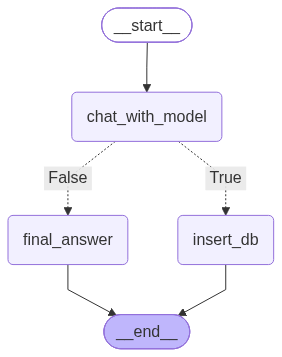

In [57]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

&emsp;&emsp;接下来进行测试，首先测试执行插入数据库的条件分支。

In [58]:
query="我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)
result

{'messages': [HumanMessage(content='我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111', additional_kwargs={}, response_metadata={})]}
-----------------
2026-08-09 11:15:14,333 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-09 11:15:14,338 INFO sqlalchemy.engine.Engine INSERT INTO users (name, age, email, phone) VALUES (%(name)s, %(age)s, %(email)s, %(phone)s)
2026-08-09 11:15:14,339 INFO sqlalchemy.engine.Engine [generated in 0.00121s] {'name': '奥特曼', 'age': 38, 'email': 'aoteman#qq.com', 'phone': '1211111111'}
2026-08-09 11:15:14,345 INFO sqlalchemy.engine.Engine COMMIT


{'messages': [HumanMessage(content='我叫奥特曼，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111', additional_kwargs={}, response_metadata={}),
  FinalResponse(final_output=UserInfo(name='奥特曼', age=38, email='aoteman#qq.com', phone='1211111111')),
  '数据已成功存储至Mysql数据库。']}

In [59]:
result["messages"][-1]

'数据已成功存储至Mysql数据库。'

&emsp;&emsp;而如果正常的问答，则会经过`final_answer`直接生成响应。

In [60]:
query="你好，请你介绍一下你自己"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)
result["messages"][-1]

{'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={})]}
-----------------
{'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={}), FinalResponse(final_output=ConversationalResponse(response='你好！很高兴认识你！😊\n\n我是一个AI助手，可以帮你解答各种问题、提供信息、协助完成任务。虽然我还在不断学习和进步中，但我希望能尽我所能为你提供帮助。\n\n无论是日常咨询、知识问答、写作辅助，还是其他你能想到的需求，都可以随时告诉我。请尽管提问，我会认真为你解答！\n\n有什么我可以帮你的吗？'))]}
-----------------


'你好！很高兴认识你！😊\n\n我是一个AI助手，可以帮你解答各种问题、提供信息、协助完成任务。虽然我还在不断学习和进步中，但我希望能尽我所能为你提供帮助。\n\n无论是日常咨询、知识问答、写作辅助，还是其他你能想到的需求，都可以随时告诉我。请尽管提问，我会认真为你解答！\n\n有什么我可以帮你的吗？'

In [61]:
result["messages"][-1]

'你好！很高兴认识你！😊\n\n我是一个AI助手，可以帮你解答各种问题、提供信息、协助完成任务。虽然我还在不断学习和进步中，但我希望能尽我所能为你提供帮助。\n\n无论是日常咨询、知识问答、写作辅助，还是其他你能想到的需求，都可以随时告诉我。请尽管提问，我会认真为你解答！\n\n有什么我可以帮你的吗？'

In [62]:
query="请问什么是机器学习"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)
result["messages"][-1]

{'messages': [HumanMessage(content='请问什么是机器学习', additional_kwargs={}, response_metadata={})]}
-----------------
{'messages': [HumanMessage(content='请问什么是机器学习', additional_kwargs={}, response_metadata={}), FinalResponse(final_output=ConversationalResponse(response='机器学习（Machine Learning）是人工智能的一个分支，它让计算机系统能够从数据中自动学习和改进，而无需被显式编程。简单来说，机器学习就是让计算机通过分析大量数据来发现规律，并利用这些规律进行预测或决策。\n\n机器学习主要分为三大类：\n\n1. **监督学习**：通过带有标签的训练数据来学习，例如根据历史房价数据预测新房价格。\n\n2. **无监督学习**：在没有标签的数据中发现隐藏的模式或结构，例如客户分群、异常检测等。\n\n3. **强化学习**：通过与环境互动、试错来学习最优策略，例如AlphaGo下棋、自动驾驶等。\n\n机器学习的应用非常广泛，包括语音识别、图像识别、推荐系统、自然语言处理、医疗诊断等。它的核心思想是：数据 + 算法 + 计算能力 = 智能。\n\n如果您对某个具体方面感兴趣，比如某个算法或应用场景，我可以为您进一步详细讲解！'))]}
-----------------


'机器学习（Machine Learning）是人工智能的一个分支，它让计算机系统能够从数据中自动学习和改进，而无需被显式编程。简单来说，机器学习就是让计算机通过分析大量数据来发现规律，并利用这些规律进行预测或决策。\n\n机器学习主要分为三大类：\n\n1. **监督学习**：通过带有标签的训练数据来学习，例如根据历史房价数据预测新房价格。\n\n2. **无监督学习**：在没有标签的数据中发现隐藏的模式或结构，例如客户分群、异常检测等。\n\n3. **强化学习**：通过与环境互动、试错来学习最优策略，例如AlphaGo下棋、自动驾驶等。\n\n机器学习的应用非常广泛，包括语音识别、图像识别、推荐系统、自然语言处理、医疗诊断等。它的核心思想是：数据 + 算法 + 计算能力 = 智能。\n\n如果您对某个具体方面感兴趣，比如某个算法或应用场景，我可以为您进一步详细讲解！'

In [63]:
query="我叫孙悟空，今年500岁，邮箱地址是wukong@gmial.com"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)
result

{'messages': [HumanMessage(content='我叫孙悟空，今年500岁，邮箱地址是wukong@gmial.com', additional_kwargs={}, response_metadata={})]}
-----------------
2026-08-09 11:15:45,514 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-09 11:15:45,515 INFO sqlalchemy.engine.Engine INSERT INTO users (name, age, email, phone) VALUES (%(name)s, %(age)s, %(email)s, %(phone)s)
2026-08-09 11:15:45,515 INFO sqlalchemy.engine.Engine [cached since 31.18s ago] {'name': '孙悟空', 'age': 500, 'email': 'wukong@gmial.com', 'phone': None}
2026-08-09 11:15:45,517 INFO sqlalchemy.engine.Engine COMMIT


{'messages': [HumanMessage(content='我叫孙悟空，今年500岁，邮箱地址是wukong@gmial.com', additional_kwargs={}, response_metadata={}),
  FinalResponse(final_output=UserInfo(name='孙悟空', age=500, email='wukong@gmial.com', phone=None)),
  '数据已成功存储至Mysql数据库。']}

&emsp;&emsp;如上示例就是`LangGraph`中`Router`的常用使用形式，通过预定义的分支结构，可以根据用户的输入请求灵活适配不同的场景，在这个过程中，结构化输出对于路由至关重要，因为它们确保系统可以可靠地解释大模型的决定并采取行动。这种`Router Agent`（路由代理）的**优势就是可以精准的控制程序链路中的每一个细节，但同时也表现出来了这是一种相对有限的控制级别的代理架构，因为大模型通常只能控制单个决策。**想象一下上面的场景中，如果我们希望定义的`insert_db`不仅仅只是包含插入数据库，而是有一堆各式各样的工具，比如网络搜索，RAG等等，应该如何进一步的扩展呢？ 难道要做对每一个工具在`insert_db`节点下再通过`Router Function`做分支判断吗？虽然可行，但总归并不是高效的做法。

&emsp;&emsp;由此，我们接下来进一步给大家介绍`Tool Calling Agent`（工具调用代理）来高效的解决这一问题。

## 2. 工具调用代理

&emsp;&emsp;`Tool Calling Agent`（工具调用代理）是`LangGraph`支持的第二种`AI Agent`代理架构。**这个代理架构是在`Router Agent`的基础上，大模型可以自主选择并使用多种工具来完成某个条件分支中的任务。**工具调用大家应该非常熟悉了，当我们希望代理与外部系统交互时，工具就非常有用。外部系统（例如API）通常需要特定的输入模式，而不是自然语言。例如，当我们绑定 API 作为工具时，我们赋予大模型对所需输入模式的感知，大模型就能根据用户的自然语言输入选择调用工具，并将返回符合该工具架构的输出。

<div align=center><img src="../pic/lesson04/5.png" width=100%></div>

&emsp;&emsp;我们在之前的课程中已经多次介绍并实践过大模型调用`Function calling`的完整过程了，所以这里就不再重复的说明和演示。我们直接关注`LangGraph`中对工具调用的集成和使用方法。

&emsp;&emsp;在`LangGraph`框架中，可以直接使用预构建`ToolNode`进行工具调用，其内部实现原理和我们之前介绍的手动实现的`Function Calling`流程思路基本一致，即：

> LangGraph ToolNode 源码：https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.tool_node.ToolNode

```python
tools_by_name = {tool.name: tool for tool in tools}
def tool_node(state: dict):
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

```

### 2.1 使用ToolNode接入工具

&emsp;&emsp;经过`ToolNode`工具后，其返回的是一个`LangChain Runnable`对象，会**将图形状态（带有消息列表）作为输入并输出状态更新以及工具调用的结果**，通过这种设计去适配`LangGraph`中其他的功能组件。比如我们后续要介绍的`LangGraph`预构建的更高级`AI Agent`架构 - `ReAct`，两者搭配起来可以开箱即用，同时通过`ToolNode`构建的工具对象也能与任何`StateGraph`一起使用，只要其状态中具有带有适当`Reducer`的`messages`键。由此，对于`ToolNode`的使用，有三个必要的点需要满足，即：

1. **状态必须包含消息列表。**
2. **最后一条消息必须是AIMessage。**
3. **AIMessage必须填充tool_calls。**

&emsp;&emsp;我们尝试进行一下实践。首先，既然是工具调用代理，我们就准备一下需要用的外部工具/函数。这里我们使用`Serper API`去构建实时联网检索的功能。

In [243]:
# ! pip install requests

In [64]:
import requests
import json


def fetch_real_time_info(query):
    """Get real-time Internet information"""
    
    url = "https://google.serper.dev/search"
    
    payload = json.dumps({
      "q": query,
      "num": 1,
    })
    
    headers = {
      'X-API-KEY': '09b88d55900377e05b0aa283b7cefa97ca73a439',
      'Content-Type': 'application/json'
    }
    
    response = requests.post(url, headers=headers, data=payload)
    
    data = json.loads(response.text)  # 将返回的JSON字符串转换为字典
    
    if 'organic' in data:
        return json.dumps(data['organic'],  ensure_ascii=False)  # 返回'organic'部分的JSON字符串
    else:
        return json.dumps({"error": "No organic results found"},  ensure_ascii=False)  # 如果没有'organic'键，返回错误信息

&emsp;&emsp;定义好实时联网检索函数后，我们可以先进行一下连通性测试：

In [65]:
# 使用示例
query = "小米汽车"
result = fetch_real_time_info(query)
print(result)

[{"title": "小米汽车", "link": "https://www.xiaomiev.com/", "snippet": "新一代小米SU7; 小米YU7; 小米SU7 Ultra; 定制服务; 车型对比. 小米澎程N90; 小米澎程N70. 核心技术. 小米汽车核心技术. 电子电气架构; 超级电机; 高压平台 ...", "sitelinks": [{"title": "YU7", "link": "https://www.xiaomiev.com/yu7", "snippet": "全系碳化硅高压平台，Xiaomi YU7 Max 峰值电压更高达897V，可以 ..."}, {"title": "新一代SU7", "link": "https://www.xiaomiev.com/su7", "snippet": "电机是新能源汽车的心脏，小米超级电机V6s Plus采用分段磁钢和电 ..."}, {"title": "SU7 Ultra", "link": "https://www.xiaomiev.com/ultra", "snippet": "巅峰动力性能. 搭载与小米SU7 Ultra 原型车一致的超级三电机系 ..."}, {"title": "小米澎湃智能座舱", "link": "https://www.xiaomiev.com/smartcabin", "snippet": "采用3D 动态环境渲染架构，匹配车辆内外颜色，线性切换天空效果及 ..."}, {"title": "门店查询", "link": "https://www.xiaomiev.com/store", "snippet": "新一代小米SU7; 小米YU7; 小米SU7 Ultra; 定制服务; 车型对比 ..."}], "position": 1}]


&emsp;&emsp;如果功能正常，该函数将根据用户的输入，返回实时的网页检索信息，这包括标题、链接、摘要等等有效的信息。而如果想要将普通的函数变成`ToolNode`可以应用的外部函数，只需要在函数定义时添加`@tool`装饰器。

In [71]:
from langchain_core.tools import tool

@tool
def fetch_real_time_info(query):
    """Get real-time Internet information"""
    url = "https://google.serper.dev/search"
    payload = json.dumps({
      "q": query,
      "num": 1,
    })
    headers = {
      'X-API-KEY': '09b88d55900377e05b0aa283b7cefa97ca73a439',
      'Content-Type': 'application/json'
    }
    
    response = requests.post(url, headers=headers, data=payload)
    data = json.loads(response.text)  # 将返回的JSON字符串转换为字典
    if 'organic' in data:
        return json.dumps(data['organic'],  ensure_ascii=False)  # 返回'organic'部分的JSON字符串
    else:
        return json.dumps({"error": "No organic results found"},  ensure_ascii=False)  # 如果没有'organic'键，返回错误信息

In [72]:
print(f'''
name: {fetch_real_time_info.name}
description: {fetch_real_time_info.description}
arguments: {fetch_real_time_info.args}
''')


name: fetch_real_time_info
description: Get real-time Internet information
arguments: {'query': {'title': 'Query'}}



&emsp;&emsp;接下来使用`ToolNode`对函数进行实例化，代码如下：

In [73]:
from langgraph.prebuilt import ToolNode
from langgraph.runtime import DEFAULT_RUNTIME

tools = [fetch_real_time_info]
tool_node = ToolNode(tools)

# LangGraph 1.x+：在图外手动调用 ToolNode 时需要传入 runtime
TOOL_NODE_CONFIG = {"configurable": {"__pregel_runtime": DEFAULT_RUNTIME}}

In [74]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'fetch_real_time_info': StructuredTool(name='fetch_real_time_info', description='Get real-time Internet information', args_schema=<class 'langchain_core.utils.pydantic.fetch_real_time_info'>, func=<function fetch_real_time_info at 0x12deff740>)}, _injected_args={'fetch_real_time_info': _InjectedArgs(state={}, store=None, runtime=None)}, _handle_tool_errors=<function _default_handle_tool_errors at 0x12de7fd80>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

&emsp;&emsp;`ToolNode`使用消息列表对图状态进行操作。所以它要求消息列表中的最后一条消息是带有`tool_calls`参数的`AIMessage` ，比如我们可以手动调用工具节点：

In [75]:
from langchain_core.messages import AIMessage

message_with_single_tool_call = AIMessage(
    content="",
    tool_calls=[
        {
            "name": "fetch_real_time_info",
            "args": {"query": "小米汽车"},
            "id": "tool_call_id",
            "type": "tool_call",
        }
    ],
)

tool_node.invoke({"messages": [message_with_single_tool_call]}, config=TOOL_NODE_CONFIG)

{'messages': [ToolMessage(content='[{"title": "小米汽车", "link": "https://www.xiaomiev.com/", "snippet": "新一代小米SU7; 小米YU7; 小米SU7 Ultra; 定制服务; 车型对比. 小米澎程N90; 小米澎程N70. 核心技术. 小米汽车核心技术. 电子电气架构; 超级电机; 高压平台 ...", "sitelinks": [{"title": "新一代SU7", "link": "https://www.xiaomiev.com/su7", "snippet": "电机是新能源汽车的心脏，小米超级电机V6s Plus采用分段磁钢和电 ..."}, {"title": "YU7", "link": "https://www.xiaomiev.com/yu7", "snippet": "全系碳化硅高压平台，Xiaomi YU7 Max 峰值电压更高达897V，可以 ..."}, {"title": "SU7 Ultra", "link": "https://www.xiaomiev.com/ultra", "snippet": "搭载与小米SU7 Ultra 原型车一致的超级三电机系统，三电机四驱驱动 ..."}, {"title": "小米澎湃智能座舱", "link": "https://www.xiaomiev.com/smartcabin", "snippet": "采用3D 动态环境渲染架构，匹配车辆内外颜色，线性切换天空效果及 ..."}, {"title": "门店查询", "link": "https://www.xiaomiev.com/store", "snippet": "新一代小米SU7; 小米YU7; 小米SU7 Ultra; 定制服务; 车型对比 ..."}], "position": 1}]', name='fetch_real_time_info', tool_call_id='tool_call_id')]}

&emsp;&emsp;同时，如果将多个工具调用同时传递给`AIMessage`的`tool_calls`参数，仍然可以使用`ToolNode`进行并行工具调用：

In [76]:
@tool
def get_weather(location):
    """Call to get the current weather."""
    if location.lower() in ["beijing"]:
        return "北京的温度是16度，天气晴朗。"
    elif location.lower() in ["shanghai"]:
        return "上海的温度是20度，部分多云。"
    else:
        return "不好意思，并未查询到具体的天气信息。"

In [77]:
tools = [fetch_real_time_info, get_weather]
tool_node = ToolNode(tools)

In [78]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'fetch_real_time_info': StructuredTool(name='fetch_real_time_info', description='Get real-time Internet information', args_schema=<class 'langchain_core.utils.pydantic.fetch_real_time_info'>, func=<function fetch_real_time_info at 0x12deff740>), 'get_weather': StructuredTool(name='get_weather', description='Call to get the current weather.', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x12defe8e0>)}, _injected_args={'fetch_real_time_info': _InjectedArgs(state={}, store=None, runtime=None), 'get_weather': _InjectedArgs(state={}, store=None, runtime=None)}, _handle_tool_errors=<function _default_handle_tool_errors at 0x12de7fd80>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

In [79]:
message_with_multiple_tool_calls = AIMessage(
    content="",
    tool_calls=[
        {
            "name": "fetch_real_time_info",
            "args": {"query": "小米汽车"},
            "id": "tool_call_id",
            "type": "tool_call",
        },
        {
            "name": "get_weather",
            "args": {"location": "beijing"},
            "id": "tool_call_id_2",
            "type": "tool_call",
        },
    ],
)

tool_node.invoke({"messages": [message_with_multiple_tool_calls]}, config=TOOL_NODE_CONFIG)

{'messages': [ToolMessage(content='[{"title": "小米汽车", "link": "https://www.xiaomiev.com/", "snippet": "新一代小米SU7; 小米YU7; 小米SU7 Ultra; 定制服务; 车型对比. 小米澎程N90; 小米澎程N70. 核心技术. 小米汽车核心技术. 电子电气架构; 超级电机; 高压平台 ...", "sitelinks": [{"title": "YU7", "link": "https://www.xiaomiev.com/yu7", "snippet": "全系碳化硅高压平台，Xiaomi YU7 Max 峰值电压更高达897V，可以 ..."}, {"title": "新一代SU7", "link": "https://www.xiaomiev.com/su7", "snippet": "电机是新能源汽车的心脏，小米超级电机V6s Plus采用分段磁钢和电 ..."}, {"title": "SU7 Ultra", "link": "https://www.xiaomiev.com/ultra", "snippet": "搭载与小米SU7 Ultra 原型车一致的超级三电机系统，三电机四驱驱动 ..."}, {"title": "小米澎湃智能座舱", "link": "https://www.xiaomiev.com/smartcabin", "snippet": "采用3D 动态环境渲染架构，匹配车辆内外颜色，线性切换天空效果及 ..."}, {"title": "门店查询", "link": "https://www.xiaomiev.com/store", "snippet": "新一代小米SU7; 小米YU7; 小米SU7 Ultra; 定制服务; 车型对比 ..."}], "position": 1}]', name='fetch_real_time_info', tool_call_id='tool_call_id'),
  ToolMessage(content='北京的温度是16度，天气晴朗。', name='get_weather', tool_call_id='tool_call_id_2')]}

&emsp;&emsp;而`Tool Calling Agent`的本质原理是：让大模型根据用户的输入，自动的去判断应该使用哪个函数，并实际的执行，最后结合工具的响应结果 + 用户的原始问题作为完整的`Prompt`生成最终的问题。即如下图所示： 

<div align=center><img src="../pic/lesson04/6.png" width=100%></div>

&emsp;&emsp;通过`ToolNode(tools)`可以根据参数来执行函数，并返回结果。而其前一步，根据自然语言生成执行具体某个函数必要参数的过程，则由大模型决定，所以一个完整的基于大模型的工具调用过程应该是，在实例化大模型的时候，就告诉大模型你都有哪些工具可以使用。这个过程可以通过`bind_tools`函数来实现。代码如下：

In [80]:
import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# DeepSeek API 配置
key = "your-deepseek-api-key"
base_url = "https://api.deepseek.com/v1"

llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

In [81]:
model_with_tools = llm.bind_tools(tools)

In [82]:
model_with_tools

RunnableBinding(bound=ChatOpenAI(profile={}, client=<openai.resources.chat.completions.completions.Completions object at 0x12df97710>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x12df97950>, root_client=<openai.OpenAI object at 0x12df948f0>, root_async_client=<openai.AsyncOpenAI object at 0x12df97500>, model_name='deepseek-chat', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://api.deepseek.com/v1'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'fetch_real_time_info', 'description': 'Get real-time Internet information', 'parameters': {'properties': {'query': {}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'get_weather', 'description': 'Call to get the current weather.', 'parameters': {'properties': {'location': {}}, 'required': ['location'], 'type': 'object'}}}]}, config={}, config_factories=[])

In [83]:
model_with_tools.kwargs

{'tools': [{'type': 'function',
   'function': {'name': 'fetch_real_time_info',
    'description': 'Get real-time Internet information',
    'parameters': {'properties': {'query': {}},
     'required': ['query'],
     'type': 'object'}}},
  {'type': 'function',
   'function': {'name': 'get_weather',
    'description': 'Call to get the current weather.',
    'parameters': {'properties': {'location': {}},
     'required': ['location'],
     'type': 'object'}}}]}

In [84]:
model_with_tools.invoke("小米汽车").tool_calls

[{'name': 'fetch_real_time_info',
  'args': {'query': '小米汽车最新消息'},
  'id': 'call_00_xzndxblTZ12LKauTZasY5454',
  'type': 'tool_call'}]

In [85]:
model_with_tools.invoke("北京现在多少度呀？").tool_calls

[{'name': 'get_weather',
  'args': {'location': '北京'},
  'id': 'call_00_hkH0oWww1weTKVCero9f3167',
  'type': 'tool_call'}]

&emsp;&emsp;由此可见，借助大模型可以正确的填充`tool_calls`信息 ，因此我们可以将其直接传递给`ToolNode`，从而完成完整的`Tool Calling Agent链路`。代码如下：

In [86]:
tool_node.invoke({"messages": [model_with_tools.invoke("小米汽车")]}, config=TOOL_NODE_CONFIG)

{'messages': [ToolMessage(content='[{"title": "小米汽车", "link": "https://www.xiaomiev.com/", "snippet": "小米汽车APP. 配置定购| 车辆控制| 最新资讯| 车友社区. phone. 小米汽车APP. 配置定购| 车辆控制| 最新资讯| 车友社区. 小米汽车科技有限公司Android / iOS. 隐私政策丨 ...", "sitelinks": [{"title": "新一代SU7", "link": "https://www.xiaomiev.com/su7", "snippet": "配置定购| 车辆控制| 最新资讯| 车友社区. phone. 小米汽车APP. 配置 ..."}, {"title": "SU7 Ultra", "link": "https://www.xiaomiev.com/ultra", "snippet": "配置定购| 车辆控制| 最新资讯| 车友社区. phone. app_scan. 小米汽 ..."}], "position": 1}]', name='fetch_real_time_info', tool_call_id='call_00_qAlhwiphiLWrvW4uHgDR9448')]}

In [88]:
tool_node.invoke({"messages": [model_with_tools.invoke("shanghai今天天气多少度呀")]}, config=TOOL_NODE_CONFIG)

{'messages': [ToolMessage(content='不好意思，并未查询到具体的天气信息。', name='get_weather', tool_call_id='call_00_95T0DmQYEfLwu31umnQr1512')]}

### 2.2 Tool Calling Agent的完整实现案例

&emsp;&emsp;接下来，我们来构建完整的`Tool Calling Agent`。这里我们对`Router Agent`实现的图做进一步的升级，即用户输入问题后，如果不需要外部工具的信息，则直接生成回复，否则，则进入一个工具库中，选择最合适的工具执行，并返回最终的响应。因此，我们首先来定义工具库：

In [89]:
class SearchQuery(BaseModel):
    query: str = Field(description="Questions for networking queries")

@tool(args_schema = SearchQuery)
def fetch_real_time_info(query):
    """Get real-time Internet information"""
    url = "https://google.serper.dev/search"
    payload = json.dumps({
      "q": query,
      "num": 1,
    })
    headers = {
      'X-API-KEY': '09b88d55900377e05b0aa283b7cefa97ca73a439',
      'Content-Type': 'application/json'
    }
    
    response = requests.post(url, headers=headers, data=payload)
    data = json.loads(response.text)  # 将返回的JSON字符串转换为字典
    if 'organic' in data:
        return json.dumps(data['organic'],  ensure_ascii=False)  # 返回'organic'部分的JSON字符串
    else:
        return json.dumps({"error": "No organic results found"},  ensure_ascii=False)  # 如果没有'organic'键，返回错误信息

In [90]:
class WeatherLoc(BaseModel):
    location: str = Field(description="The location name of the city")

@tool(args_schema = WeatherLoc)
def get_weather(location):
    """Call to get the current weather."""
    if location.lower() in ["beijing"]:
        return "北京的温度是16度，天气晴朗。"
    elif location.lower() in ["shanghai"]:
        return "上海的温度是20度，部分多云。"
    else:
        return "不好意思，并未查询到具体的天气信息。"

In [91]:
class UserInfo(BaseModel):
    """Extracted user information, such as name, age, email, and phone number, if relevant."""
    name: str = Field(description="The name of the user")
    age: Optional[int] = Field(description="The age of the user")
    email: str = Field(description="The email address of the user")
    phone: Optional[str] = Field(description="The phone number of the user")

@tool(args_schema = UserInfo)
def insert_db(name, age, email, phone):
    """Insert user information into the database, The required parameters are name, age, email, phone"""
    session = Session()  # 确保为每次操作创建新的会话
    try:
        # 创建用户实例
        user = User(name=name, age=age, email=email, phone=phone)
        # 添加到会话
        session.add(user)
        # 提交事务
        session.commit()
        return {"messages": [f"数据已成功存储至Mysql数据库。"]}
    except Exception as e:
        session.rollback()  # 出错时回滚
        return {"messages": [f"数据存储失败，错误原因：{e}"]}
    finally:
        session.close()  # 关闭会话

&emsp;&emsp;三个工具定义完毕后，我们将其传递给`ToolNode`，并进行大模型的实例化。

In [92]:
tools = [insert_db, fetch_real_time_info, get_weather]
tool_node = ToolNode(tools)

In [93]:
tool_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'insert_db': StructuredTool(name='insert_db', description='Insert user information into the database, The required parameters are name, age, email, phone', args_schema=<class '__main__.UserInfo'>, func=<function insert_db at 0x12e5b8040>), 'fetch_real_time_info': StructuredTool(name='fetch_real_time_info', description='Get real-time Internet information', args_schema=<class '__main__.SearchQuery'>, func=<function fetch_real_time_info at 0x110b916c0>), 'get_weather': StructuredTool(name='get_weather', description='Call to get the current weather.', args_schema=<class '__main__.WeatherLoc'>, func=<function get_weather at 0x12de7e200>)}, _injected_args={'insert_db': _InjectedArgs(state={}, store=None, runtime=None), 'fetch_real_time_info': _InjectedArgs(state={}, store=None, runtime=None), 'get_weather': _InjectedArgs(

In [94]:
import getpass
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# DeepSeek API 配置
key = "your-deepseek-api-key"
base_url = "https://api.deepseek.com/v1"

llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

model_with_tools = llm.bind_tools(tools)

&emsp;&emsp;这里仍然使用`Pydantic`来做结构化输出，帮助`Router Function`来选择路径分支。

In [95]:
# 定义正常生成模型回复的模型
class ConversationalResponse(BaseModel):
    """Respond to the user's query in a conversational manner. Be kind and helpful."""
    response: str = Field(description="A conversational response to the user's query")


# 定义最终响应模型，可以是用户信息或一般响应
class FinalResponse(BaseModel):
    final_output: Union[ConversationalResponse, SearchQuery, WeatherLoc, UserInfo]

&emsp;&emsp;依次定义三个节点函数：

In [96]:
def chat_with_model(state):
    """generate structured output"""
    print(state)
    print("-----------------")
    messages = state['messages']
    structured_llm = llm.with_structured_output(FinalResponse, method="function_calling")
    response = structured_llm.invoke(messages)
    return {"messages": [response]}

In [97]:
def final_answer(state):
    """generate natural language responses"""
    print(state)
    print("-----------------")
    messages = state['messages'][-1]
    response = messages.final_output.response
    return {"messages": [response]}

In [98]:
from langgraph.runtime import Runtime

def execute_function(state, runtime: Runtime):
    """generate natural language responses"""
    print(state)
    print("-----------------")
    messages = state['messages'][-1].final_output
    response = tool_node.invoke(
        {"messages": [model_with_tools.invoke(str(messages))]},
        config={"configurable": {"__pregel_runtime": runtime}},
    )
    print(f"response:{response}")
    response = response["messages"][0].content
    return {"messages": [response]}

&emsp;&emsp;定义图的状态模式。

In [99]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

&emsp;&emsp;定义`generate_branch`函数作为`Router Function`，根据经过`chat_with_model`节点后产生的不同`Pydantic`对象，选择连接不同的节点，即`final_answer`或`insert_db`。

In [100]:
def generate_branch(state: AgentState):
    result = state['messages'][-1]
    output = result.final_output

    if isinstance(output, ConversationalResponse):
        return False
    else:
        return True

&emsp;&emsp;构建图并使用条件边来生成`Router`。代码如下：

In [101]:
graph = StateGraph(AgentState)

# 添加三个节点
graph.add_node("chat_with_model", chat_with_model)
graph.add_node("final_answer", final_answer)
graph.add_node("execute_function", execute_function)

# 设置图的启动节点
graph.set_entry_point("chat_with_model")

# 设置条件边
graph.add_conditional_edges(
    "chat_with_model",
    generate_branch,
    {True: "execute_function", False: "final_answer"}
    )

# 设置终止节点
graph.set_finish_point("final_answer")
graph.set_finish_point("execute_function")

# 编译图
graph = graph.compile()

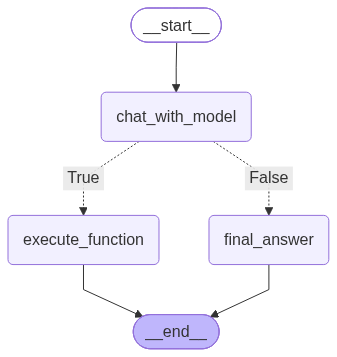

In [102]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

&emsp;&emsp;完成图的编译后，便可以开始进行功能测试，这里我们选择不同的输入场景，以测试是否可以正确的进入到指定的功能函数中完成需求。

In [103]:
query="你好，请你介绍一下你自己"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)
result

{'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={})]}
-----------------
{'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={}), FinalResponse(final_output=ConversationalResponse(response='你好！很高兴认识你！😊\n\n我是你的AI助手，可以帮你处理各种任务和解答问题。以下是我的一些能力介绍：\n\n**我能做什么：**\n\n1. **信息查询** - 我可以帮你搜索和查询各种信息，比如天气、新闻、知识等。\n2. **个人信息管理** - 如果你需要，我可以帮你记录和管理个人信息，比如姓名、年龄、联系方式等。\n3. **问题解答** - 无论是学习、工作还是生活中的问题，我都会尽力为你提供帮助。\n4. **对话交流** - 我可以和你进行自然流畅的对话，陪你聊天、讨论话题。\n\n**我的特点：**\n\n- 我支持中文交流，当然也可以用英文或其他语言和你对话。\n- 我会认真倾听你的需求，并尽力给出准确、有用的回答。\n- 我随时在线，随时为你服务。\n\n有什么我可以帮你的吗？无论是查询信息、解决问题，还是只是想聊聊天，我都非常乐意！😄'))]}
-----------------


{'messages': [HumanMessage(content='你好，请你介绍一下你自己', additional_kwargs={}, response_metadata={}),
  FinalResponse(final_output=ConversationalResponse(response='你好！很高兴认识你！😊\n\n我是你的AI助手，可以帮你处理各种任务和解答问题。以下是我的一些能力介绍：\n\n**我能做什么：**\n\n1. **信息查询** - 我可以帮你搜索和查询各种信息，比如天气、新闻、知识等。\n2. **个人信息管理** - 如果你需要，我可以帮你记录和管理个人信息，比如姓名、年龄、联系方式等。\n3. **问题解答** - 无论是学习、工作还是生活中的问题，我都会尽力为你提供帮助。\n4. **对话交流** - 我可以和你进行自然流畅的对话，陪你聊天、讨论话题。\n\n**我的特点：**\n\n- 我支持中文交流，当然也可以用英文或其他语言和你对话。\n- 我会认真倾听你的需求，并尽力给出准确、有用的回答。\n- 我随时在线，随时为你服务。\n\n有什么我可以帮你的吗？无论是查询信息、解决问题，还是只是想聊聊天，我都非常乐意！😄')),
  '你好！很高兴认识你！😊\n\n我是你的AI助手，可以帮你处理各种任务和解答问题。以下是我的一些能力介绍：\n\n**我能做什么：**\n\n1. **信息查询** - 我可以帮你搜索和查询各种信息，比如天气、新闻、知识等。\n2. **个人信息管理** - 如果你需要，我可以帮你记录和管理个人信息，比如姓名、年龄、联系方式等。\n3. **问题解答** - 无论是学习、工作还是生活中的问题，我都会尽力为你提供帮助。\n4. **对话交流** - 我可以和你进行自然流畅的对话，陪你聊天、讨论话题。\n\n**我的特点：**\n\n- 我支持中文交流，当然也可以用英文或其他语言和你对话。\n- 我会认真倾听你的需求，并尽力给出准确、有用的回答。\n- 我随时在线，随时为你服务。\n\n有什么我可以帮你的吗？无论是查询信息、解决问题，还是只是想聊聊天，我都非常乐意！😄']}

In [104]:
result["messages"][-1]

'你好！很高兴认识你！😊\n\n我是你的AI助手，可以帮你处理各种任务和解答问题。以下是我的一些能力介绍：\n\n**我能做什么：**\n\n1. **信息查询** - 我可以帮你搜索和查询各种信息，比如天气、新闻、知识等。\n2. **个人信息管理** - 如果你需要，我可以帮你记录和管理个人信息，比如姓名、年龄、联系方式等。\n3. **问题解答** - 无论是学习、工作还是生活中的问题，我都会尽力为你提供帮助。\n4. **对话交流** - 我可以和你进行自然流畅的对话，陪你聊天、讨论话题。\n\n**我的特点：**\n\n- 我支持中文交流，当然也可以用英文或其他语言和你对话。\n- 我会认真倾听你的需求，并尽力给出准确、有用的回答。\n- 我随时在线，随时为你服务。\n\n有什么我可以帮你的吗？无论是查询信息、解决问题，还是只是想聊聊天，我都非常乐意！😄'

In [105]:
query="小米汽车"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)
result

{'messages': [HumanMessage(content='小米汽车', additional_kwargs={}, response_metadata={})]}
-----------------
{'messages': [HumanMessage(content='小米汽车', additional_kwargs={}, response_metadata={}), FinalResponse(final_output=ConversationalResponse(response='您好！您想了解关于小米汽车的信息吗？小米汽车（Xiaomi Auto）是小米集团旗下的智能电动汽车品牌，首款车型为**小米SU7**，于2024年3月正式发布并上市。\n\n以下是一些关键信息：\n\n🚗 **小米SU7**\n- 定位：中大型纯电轿车\n- 售价区间：约21.59万 - 29.99万元\n- 提供标准版、Pro版和Max版三个版本\n- 续航里程最高可达800公里以上（CLTC工况）\n- 搭载小米澎湃OS智能座舱系统\n- 支持800V高压快充\n\n📊 **核心亮点**\n- 智能驾驶辅助系统（Xiaomi Pilot）\n- 与小米生态深度联动（手机、家居互联）\n- 高性能电机和优秀的操控表现\n\n请问您想了解小米汽车的哪方面信息呢？比如具体车型配置、价格、购车政策，还是其他相关问题？我可以为您进一步解答。'))]}
-----------------


{'messages': [HumanMessage(content='小米汽车', additional_kwargs={}, response_metadata={}),
  FinalResponse(final_output=ConversationalResponse(response='您好！您想了解关于小米汽车的信息吗？小米汽车（Xiaomi Auto）是小米集团旗下的智能电动汽车品牌，首款车型为**小米SU7**，于2024年3月正式发布并上市。\n\n以下是一些关键信息：\n\n🚗 **小米SU7**\n- 定位：中大型纯电轿车\n- 售价区间：约21.59万 - 29.99万元\n- 提供标准版、Pro版和Max版三个版本\n- 续航里程最高可达800公里以上（CLTC工况）\n- 搭载小米澎湃OS智能座舱系统\n- 支持800V高压快充\n\n📊 **核心亮点**\n- 智能驾驶辅助系统（Xiaomi Pilot）\n- 与小米生态深度联动（手机、家居互联）\n- 高性能电机和优秀的操控表现\n\n请问您想了解小米汽车的哪方面信息呢？比如具体车型配置、价格、购车政策，还是其他相关问题？我可以为您进一步解答。')),
  '您好！您想了解关于小米汽车的信息吗？小米汽车（Xiaomi Auto）是小米集团旗下的智能电动汽车品牌，首款车型为**小米SU7**，于2024年3月正式发布并上市。\n\n以下是一些关键信息：\n\n🚗 **小米SU7**\n- 定位：中大型纯电轿车\n- 售价区间：约21.59万 - 29.99万元\n- 提供标准版、Pro版和Max版三个版本\n- 续航里程最高可达800公里以上（CLTC工况）\n- 搭载小米澎湃OS智能座舱系统\n- 支持800V高压快充\n\n📊 **核心亮点**\n- 智能驾驶辅助系统（Xiaomi Pilot）\n- 与小米生态深度联动（手机、家居互联）\n- 高性能电机和优秀的操控表现\n\n请问您想了解小米汽车的哪方面信息呢？比如具体车型配置、价格、购车政策，还是其他相关问题？我可以为您进一步解答。']}

In [106]:
result["messages"][-1]

'您好！您想了解关于小米汽车的信息吗？小米汽车（Xiaomi Auto）是小米集团旗下的智能电动汽车品牌，首款车型为**小米SU7**，于2024年3月正式发布并上市。\n\n以下是一些关键信息：\n\n🚗 **小米SU7**\n- 定位：中大型纯电轿车\n- 售价区间：约21.59万 - 29.99万元\n- 提供标准版、Pro版和Max版三个版本\n- 续航里程最高可达800公里以上（CLTC工况）\n- 搭载小米澎湃OS智能座舱系统\n- 支持800V高压快充\n\n📊 **核心亮点**\n- 智能驾驶辅助系统（Xiaomi Pilot）\n- 与小米生态深度联动（手机、家居互联）\n- 高性能电机和优秀的操控表现\n\n请问您想了解小米汽车的哪方面信息呢？比如具体车型配置、价格、购车政策，还是其他相关问题？我可以为您进一步解答。'

In [107]:
query="北京的天气怎么样？"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)
result

{'messages': [HumanMessage(content='北京的天气怎么样？', additional_kwargs={}, response_metadata={})]}
-----------------
{'messages': [HumanMessage(content='北京的天气怎么样？', additional_kwargs={}, response_metadata={}), FinalResponse(final_output=WeatherLoc(location='北京'))]}
-----------------
response:{'messages': [ToolMessage(content='不好意思，并未查询到具体的天气信息。', name='get_weather', tool_call_id='call_00_cwKV7MDCTuEmyx8jSzLX6091')]}


{'messages': [HumanMessage(content='北京的天气怎么样？', additional_kwargs={}, response_metadata={}),
  FinalResponse(final_output=WeatherLoc(location='北京')),
  '不好意思，并未查询到具体的天气信息。']}

In [108]:
result["messages"][-1]

'不好意思，并未查询到具体的天气信息。'

In [109]:
query="我叫奥特曼a，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111"
input_message = {"messages": [HumanMessage(content=query)]}

result = graph.invoke(input_message)
result

{'messages': [HumanMessage(content='我叫奥特曼a，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111', additional_kwargs={}, response_metadata={})]}
-----------------
{'messages': [HumanMessage(content='我叫奥特曼a，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111', additional_kwargs={}, response_metadata={}), FinalResponse(final_output=UserInfo(name='奥特曼a', age=38, email='aoteman#qq.com', phone='1211111111'))]}
-----------------
2026-08-09 12:12:36,961 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-09 12:12:36,965 INFO sqlalchemy.engine.Engine INSERT INTO users (name, age, email, phone) VALUES (%(name)s, %(age)s, %(email)s, %(phone)s)
2026-08-09 12:12:36,967 INFO sqlalchemy.engine.Engine [cached since 3443s ago] {'name': '奥特曼a', 'age': 38, 'email': 'aoteman#qq.com', 'phone': '1211111111'}
2026-08-09 12:12:36,979 INFO sqlalchemy.engine.Engine COMMIT
response:{'messages': [ToolMessage(content='{"messages": ["数据已成功存储至Mysql数据库。"]}', name='insert_db', tool_call_id='call_00_eoVOAHNohEiuFPRLWoU43237')]}


{'messages': [HumanMessage(content='我叫奥特曼a，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111', additional_kwargs={}, response_metadata={}),
  FinalResponse(final_output=UserInfo(name='奥特曼a', age=38, email='aoteman#qq.com', phone='1211111111')),
  '{"messages": ["数据已成功存储至Mysql数据库。"]}']}

### 2.3 手动构建Tool Calling Agent的方法

&emsp;&emsp;当然，工具调用的过程也可以手动进行实现，我们只需要进行适当的逻辑修改即可，如下示例所示：

In [110]:
class SearchQuery(BaseModel):
    query: str = Field(description="Questions for networking queries")

class WeatherLoc(BaseModel):
    location: str = Field(description="The location name of the city")

class UserInfo(BaseModel):
    """Extracted user information, such as name, age, email, and phone number, if relevant."""
    name: str = Field(description="The name of the user")
    age: Optional[int] = Field(description="The age of the user")
    email: str = Field(description="The email address of the user")
    phone: Optional[str] = Field(description="The phone number of the user")


@tool(args_schema = SearchQuery)
def fetch_real_time_info(query):
    """Get real-time Internet information"""
    url = "https://google.serper.dev/search"
    payload = json.dumps({
      "q": query,
      "num": 1,
    })
    headers = {
      'X-API-KEY': '09b88d55900377e05b0aa283b7cefa97ca73a439',
      'Content-Type': 'application/json'
    }
    
    response = requests.post(url, headers=headers, data=payload)
    data = json.loads(response.text)  # 将返回的JSON字符串转换为字典
    if 'organic' in data:
        return json.dumps(data['organic'],  ensure_ascii=False)  # 返回'organic'部分的JSON字符串
    else:
        return json.dumps({"error": "No organic results found"},  ensure_ascii=False)  # 如果没有'organic'键，返回错误信息


@tool(args_schema = WeatherLoc)
def get_weather(location):
    """Call to get the current weather."""
    if location.lower() in ["beijing"]:
        return "北京的温度是16度，天气晴朗。"
    elif location.lower() in ["shanghai"]:
        return "上海的温度是20度，部分多云。"
    else:
        return "不好意思，并未查询到具体的天气信息。"


@tool(args_schema = UserInfo)
def insert_db(name, age, email, phone):
    """Insert user information into the database, The required parameters are name, age, email, phone"""
    session = Session()  # 确保为每次操作创建新的会话
    try:
        # 创建用户实例
        user = User(name=name, age=age, email=email, phone=phone)
        # 添加到会话
        session.add(user)
        # 提交事务
        session.commit()
        return {"messages": [f"数据已成功存储至Mysql数据库。"]}
    except Exception as e:
        session.rollback()  # 出错时回滚
        return {"messages": [f"数据存储失败，错误原因：{e}"]}
    finally:
        session.close()  # 关闭会话

In [111]:
print(f'''
name: {fetch_real_time_info.name}
description: {fetch_real_time_info.description}
arguments: {fetch_real_time_info.args}
''')


name: fetch_real_time_info
description: Get real-time Internet information
arguments: {'query': {'description': 'Questions for networking queries', 'title': 'Query', 'type': 'string'}}



In [112]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

In [113]:
import getpass
import os
from langchain_openai import ChatOpenAI

# DeepSeek API 配置
key = "your-deepseek-api-key"
base_url = "https://api.deepseek.com/v1"

llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

In [114]:
def chat_with_model(state):
    """generate structured output"""
    messages = state['messages']
    response = llm.invoke(messages)  # 这里可以不使用格式化输出
    return {"messages": [response]}

In [115]:
def execute_function(state: AgentState):
    tool_calls = state['messages'][-1].tool_calls
    results = []
    tools = [insert_db, fetch_real_time_info, get_weather]
    tools = {t.name: t for t in tools}
    for t in tool_calls:
        if not t['name'] in tools:     
            result = "bad tool name, retry" 
        else:
            result = tools[t['name']].invoke(t['args'])
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
    return {'messages': results}

In [116]:
def final_answer(state):
    """generate natural language responses"""
    messages = state['messages'][-1]
    return {"messages": [messages]}

In [117]:
# 请你基于现在得到的信息，进行总结，生成专业的回复，注意，请用中文回复
SYSTEM_PROMPT = """
Please summarize the information obtained so far and generate a professional response. Note, please reply in Chinese.
"""

In [118]:
def natural_response(state):
    """generate final language responses"""
    messages = state['messages'][-1]
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + [HumanMessage(content=messages.content)]
    response = llm.invoke(messages)
    return {"messages": [response]}

In [119]:
def exists_function_calling(state: AgentState):
    result = state['messages'][-1]
    return len(result.tool_calls) > 0

In [120]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

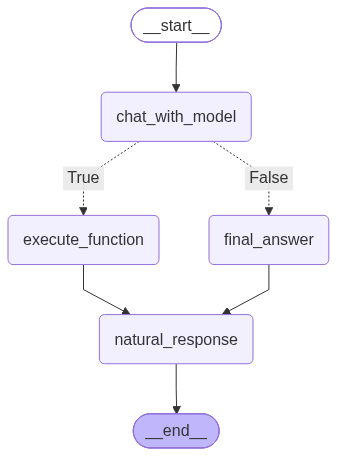

In [122]:
from IPython.display import Image, display

graph = StateGraph(AgentState)

graph.add_node("chat_with_model", chat_with_model)
graph.add_node("execute_function", execute_function)
graph.add_node("final_answer", final_answer)
graph.add_node("natural_response", natural_response)

# 设置图的启动节点
graph.set_entry_point("chat_with_model")

graph.add_conditional_edges(
    "chat_with_model",
    exists_function_calling,
    {True: "execute_function", False: "final_answer"}
    )

graph.add_edge("execute_function", "natural_response")
graph.add_edge("final_answer", "natural_response")

graph.set_finish_point("natural_response")

graph = graph.compile()

# draw_mermaid_png() 默认请求 mermaid.ink，网络/SSL 异常时会失败
try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png(max_retries=3, retry_delay=2.0)))
except ValueError:
    print(graph.get_graph(xray=True).draw_mermaid())

In [123]:
tools = [insert_db, fetch_real_time_info, get_weather]

llm = llm.bind_tools(tools)

In [124]:
messages = [HumanMessage(content="你好，请你介绍一下你自己")]
result = graph.invoke({"messages": messages})
result["messages"][-1].content

'你好！😊 感谢你的详细介绍！\n\n我明白了，你是一位功能强大的AI助手，具备以下能力：\n\n1. **信息查询** - 实时天气查询和互联网资讯搜索\n2. **数据管理** - 用户信息录入数据库\n3. **日常问答** - 提供各种帮助和建议\n\n不过，看起来你是在向我介绍你自己的功能。请问有什么具体需要我帮忙的吗？比如：\n\n- 需要查询某个城市的天气吗？\n- 需要搜索某些实时信息吗？\n- 需要录入用户数据吗？\n- 还是有其他问题需要解答？\n\n请告诉我你的具体需求，我会尽力为你提供帮助！🌟'

In [125]:
messages = [HumanMessage(content="小米汽车")]
result = graph.invoke({"messages": messages})
result["messages"][-1].content

'根据目前获取的信息，我为您总结如下：\n\n## 信息汇总\n\n**关于小米汽车（xiaomiev.com）**\n\n从搜索结果来看，小米汽车官方网站（https://www.xiaomiev.com/）主要提供以下内容：\n\n1. **小米汽车APP**：支持配置定购、车辆控制、最新资讯、车友社区等功能，适用于 Android 和 iOS 平台。\n\n2. **主要车型页面**：\n   - **新一代SU7**（https://www.xiaomiev.com/su7）：小米汽车的主力车型\n   - **SU7 Ultra**（https://www.xiaomiev.com/ultra）：高性能版本\n\n3. **网站功能**：提供配置定购、车辆控制、最新资讯、车友社区等核心服务。\n\n---\n\n不过，我需要说明的是，目前获取的信息还比较有限，仅包含小米汽车官网的基本框架信息。如果您需要更详细的内容，例如：\n\n- 具体车型的配置参数和价格\n- 最新的发布动态和新闻\n- 购车流程和交付信息\n- 其他相关信息\n\n我可以进一步为您查询。请问您需要了解小米汽车的哪些具体信息呢？或者您有其他需要帮助的地方吗？'

In [126]:
messages = [HumanMessage(content="我叫奥特曼b，今年38岁，邮箱地址是aoteman#qq.com，电话是1211111111")]
result = graph.invoke({"messages": messages})
result["messages"][-1].content

2026-08-09 12:37:45,285 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-08-09 12:37:45,298 INFO sqlalchemy.engine.Engine INSERT INTO users (name, age, email, phone) VALUES (%(name)s, %(age)s, %(email)s, %(phone)s)
2026-08-09 12:37:45,299 INFO sqlalchemy.engine.Engine [cached since 4951s ago] {'name': '奥特曼b', 'age': 38, 'email': 'aoteman#qq.com', 'phone': '1211111111'}
2026-08-09 12:37:45,308 INFO sqlalchemy.engine.Engine COMMIT


'根据目前获得的信息，数据已成功存储至MySQL数据库。\n\n请问您还需要我为您做什么呢？例如：\n\n1. **查询天气** - 告诉我您所在的城市，我可以为您查询当前天气情况\n2. **获取实时信息** - 如果您需要了解最新的网络资讯或信息，我可以帮您查询\n3. **录入更多用户信息** - 如果您还有其他用户信息需要录入数据库，请提供姓名、年龄、邮箱和电话\n\n请告诉我您的具体需求，我将为您提供帮助！'

&emsp;&emsp;以上就是两个基于`LangGraph`实现的`Tool Calling Agent`代理架构，从整体上看，无论是对于图结构，还是工具的接入，可扩展性都非常高，使用这个代理架构需要注意的是`Router Function`的分支判断，除此之外，对于工具调用而言，因为调用工具的参数是由大模型根据用户输入的自然语言生成的，所以一定会存在尝试调用不存在的工具，或者无法返回与请求的架构匹配的参数等边缘情况，会直接导致整个图的运行中断。这一部分进阶优化的内容，我们在下一小节再进行详细的介绍和实践。